In [34]:
openai_key="YOUR KEY"

In [35]:
DATA_FILES = [
    "predictions_real1.xlsx",
    "predictions_real3.xlsx",
    "predictions_real4.xlsx",
    "predictions_real5.xlsx",
    "predictions_real6.xlsx",
]

In [36]:
import os, json, time, math
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

from openai import OpenAI

In [37]:
def read_excel_any(path: str) -> pd.DataFrame:
    df = pd.read_excel(path, engine="openpyxl")
    df.columns = [c.strip().lower() for c in df.columns]
    colmap = {}
    if "user" in df.columns: colmap["user"] = "prompt"
    if "question" in df.columns: colmap["question"] = "prompt"
    if "gold" in df.columns: colmap["gold"] = "gold"
    if "prediction" in df.columns: colmap["prediction"] = "prediction"
    df = df.rename(columns=colmap)
    needed = {"prompt","gold","prediction"}
    missing = needed - set(df.columns)
    assert not missing, f"{path} missing columns: {missing}"
    return df[["prompt","gold","prediction"]].copy()

In [38]:
def _model_from_filename(fname: str) -> str:
    stem = Path(fname).stem  
    return "QWEN3_4B instruct base" if stem == "predictions_real1" else stem

In [39]:
def _uniq_preserve(seq):
    seen, out = set(), []
    for x in seq:
        s = "" if (x is None or (isinstance(x, float) and np.isnan(x))) else str(x)
        if s and s not in seen:
            seen.add(s); out.append(s)
    return out

frames = []
for f in DATA_FILES:
    df = read_excel_any(f)
    df["__source_file__"] = f
    frames.append(df)

In [40]:
frames

[                           prompt  \
 0   成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？   
 1   成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？   
 2   成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？   
 3               成都有哪些适合中学生的科技类场馆？   
 4               成都有哪些适合中学生的科技类场馆？   
 5               成都有哪些适合中学生的科技类场馆？   
 6        第一次去成都大熊猫繁育研究基地，有哪些实用建议？   
 7        第一次去成都大熊猫繁育研究基地，有哪些实用建议？   
 8        第一次去成都大熊猫繁育研究基地，有哪些实用建议？   
 9             除了火锅，成都还有哪些地道小吃值得尝？   
 10            除了火锅，成都还有哪些地道小吃值得尝？   
 11            除了火锅，成都还有哪些地道小吃值得尝？   
 12                   成都的公共交通系统怎么样   
 13                   成都的公共交通系统怎么样   
 14                   成都的公共交通系统怎么样   
 
                                                  gold  \
 0   可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息可...   
 1   本地的CGT48女团非常出名，建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序...   
 2   建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准，优先选择视线不...   
 3   成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动模...   
 4   成都自然博物馆：生命科学与地球科学主题较完整，适合科普入门。\n• 参观顺序：先预约→看场馆...   
 5   可以前往四川科技馆。• 预约：提前在官方渠道预约入馆时段；节假日尽量避峰。

In [28]:
from pydantic import BaseModel, Field

In [41]:
df_raw = pd.concat(frames, ignore_index=True)
# Row index within each file, original ordering corresponds to triplets
df_raw["__row_idx_in_file__"] = df_raw.groupby("__source_file__").cumcount()
# Triplet id: 0-2, 3-5, 6-8, 9-11, 12-14;  five prompts per file
df_raw["__triplet_id__"] = (df_raw["__row_idx_in_file__"] // 3).astype(int)
df_raw["prompt_set"] = df_raw["__source_file__"].astype(str) + "::set" + (df_raw["__triplet_id__"] + 1).astype(str)

# 3 distinct gold references per prompt_set
refs = (df_raw.groupby(["__source_file__", "prompt_set"], sort=False)["gold"]
              .apply(lambda s: _uniq_preserve(s.dropna().tolist()))
              .reset_index(name="references"))

# Run id (1..3) within each prompt_set (three model outputs / seeds)
df_raw["run"] = df_raw.groupby(["__source_file__", "prompt_set"]).cumcount() + 1
df_raw["model"] = df_raw["__source_file__"].map(_model_from_filename)
df_raw["prompt_id"] = df_raw["__triplet_id__"].astype(int)
df_raw["set_id"]    = df_raw["prompt_set"]

tidy = (df_raw.merge(refs, on=["__source_file__","prompt_set"], how="left")
              .rename(columns={"prediction":"output","prompt":"prompt_text"})
              [["set_id","prompt_id","model","run","output","references","prompt_text"]]
              .sort_values(["model","set_id","prompt_id","run"], kind="stable")
              .reset_index(drop=True))

display(tidy.head(8))

,set_id,prompt_id,model,run,output,references,prompt_text
0,predictions_real1.xlsx::set1,0,QWEN3_4B instruct base,1,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？
1,predictions_real1.xlsx::set1,0,QWEN3_4B instruct base,2,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？
2,predictions_real1.xlsx::set1,0,QWEN3_4B instruct base,3,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？
3,predictions_real1.xlsx::set2,1,QWEN3_4B instruct base,1,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信...,[成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动...,成都有哪些适合中学生的科技类场馆？
4,predictions_real1.xlsx::set2,1,QWEN3_4B instruct base,2,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信...,[成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动...,成都有哪些适合中学生的科技类场馆？
5,predictions_real1.xlsx::set2,1,QWEN3_4B instruct base,3,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信...,[成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动...,成都有哪些适合中学生的科技类场馆？
6,predictions_real1.xlsx::set3,2,QWEN3_4B instruct base,1,去成都大熊猫繁育研究基地，以下是一些实用建议（基于官网及公开信息）：\n\n1. **开放时...,[• 时段：尽量上午入园，活动更频繁；避开节假日高峰。\n• 路线：先园区核心熊猫区→幼年熊...,第一次去成都大熊猫繁育研究基地，有哪些实用建议？
7,predictions_real1.xlsx::set3,2,QWEN3_4B instruct base,2,去成都大熊猫繁育研究基地，以下是一些实用建议（基于官网及公开信息）：\n\n1. **开放时...,[• 时段：尽量上午入园，活动更频繁；避开节假日高峰。\n• 路线：先园区核心熊猫区→幼年熊...,第一次去成都大熊猫繁育研究基地，有哪些实用建议？


In [42]:
need_cols = {"set_id","prompt_id","model","run","output","prompt_text"}
missing = need_cols - set(tidy.columns)
missing

set()

# Calling 

In [43]:
assert "tidy" in globals(), "Expect a DataFrame named `tidy`."
need = {"set_id","prompt_id","model","run","output","prompt_text"}
missing = need - set(tidy.columns)
assert not missing, f"`tidy` is missing columns: {missing}"

client = OpenAI(api_key=openai_key)
JUDGE_MODEL = "gpt-5-nano"     # nano judge
TEMPERATURE = 0.0              # Openai baned 

SYSTEM_PROMPT = (
    "You are an expert evaluator of Chinese tourism Q&A.\n"
    "Evaluate ONLY from the given question and the answer—no external references or tools.\n"
    "Be conservative on correctness; penalize factual errors, contradictions, or unsafe advice.\n"
    "Output MUST match the schema."
)

In [22]:
USER_TEMPLATE = """\
Rubric (each 0–3):

[Relevance]
0: The answer is entirely irrelevant to the question.
1: The answer is somewhat relevant to the question.
2: The answer is relevant to the question.
3: The answer is highly relevant to the question.

[Clarity]
0: The answer is extremely difficult to understand or has poor grammar and structure.
1: The answer is somewhat difficult to understand or has grammatical errors.
2: The answer is clear, with only a few grammatical errors or room for improvement.
3: The answer is very clear, well structured, has no grammatical errors and is easy to understand.

[Correctness]
0: There are serious problems or errors in the answer and the answer is not very usable.
1: There are some errors in the answer; parts need verification by searching.
2: The answer is error-free, with only a few confusing elements.
3: The answer is error-free and instructive, providing a better experience for travellers.

Question (prompt):
{prompt}

Model answer:
{answer}

Instructions:
- Provide integer scores in [0,3] for relevance, clarity, correctness.
- Sum them to a total in [0,9].
- Provide a brief explanation (<120 words) for each dimension.
"""

In [26]:
JSON_SCHEMA = {
    "name": "EvalScores",
    "strict": True,
    "schema": {
        "type": "object",
        "additionalProperties": False,
        "properties": {
            "relevance": {
                "type": "object",
                "additionalProperties": False,
                "properties": {
                    "score": {"type": "integer", "minimum": 0, "maximum": 3},
                    "explanation": {"type": "string"}
                },
                "required": ["score","explanation"]
            },
            "clarity": {
                "type": "object",
                "additionalProperties": False,
                "properties": {
                    "score": {"type": "integer", "minimum": 0, "maximum": 3},
                    "explanation": {"type": "string"}
                },
                "required": ["score","explanation"]
            },
            "correctness": {
                "type": "object",
                "additionalProperties": False,
                "properties": {
                    "score": {"type": "integer", "minimum": 0, "maximum": 3},
                    "explanation": {"type": "string"}
                },
                "required": ["score","explanation"]
            },
            "total": {"type": "integer", "minimum": 0, "maximum": 9}
        },
        "required": ["relevance","clarity","correctness","total"]
    }
}

In [29]:
def _to_str(x):
    if x is None: return ""
    if isinstance(x, float) and math.isnan(x): return ""
    return str(x)

def _validate_payload(d: dict) -> dict:
    try:
        r = max(0, min(3, int(d.get("relevance", {}).get("score", 0))))
        c = max(0, min(3, int(d.get("clarity", {}).get("score", 0))))
        k = max(0, min(3, int(d.get("correctness", {}).get("score", 0))))
        return {
            "relevance":  {"score": r, "explanation": d.get("relevance", {}).get("explanation","")},
            "clarity":    {"score": c, "explanation": d.get("clarity", {}).get("explanation","")},
            "correctness":{"score": k, "explanation": d.get("correctness", {}).get("explanation","")},
            "total": r + c + k
        }
    except Exception:
        return {
            "relevance":  {"score":0,"explanation":"Invalid response"},
            "clarity":    {"score":0,"explanation":"Invalid response"},
            "correctness":{"score":0,"explanation":"Invalid response"},
            "total": 0
        }

In [30]:
@retry(reraise=True, stop=stop_after_attempt(5),
       wait=wait_exponential(multiplier=1.5, min=1, max=20),
       retry=retry_if_exception_type(Exception))
def judge_one(prompt_text: str, answer_text: str) -> dict:
    messages = [
        {"role":"system","content": SYSTEM_PROMPT},
        {"role":"user","content": USER_TEMPLATE.format(
            prompt=_to_str(prompt_text).strip(),
            answer=_to_str(answer_text).strip()
        )},
    ]

    # First attempt: include temperature (many models accept 0.0)
    req = {
        "model": JUDGE_MODEL,
        "messages": messages,
        "response_format": {"type":"json_schema", "json_schema": JSON_SCHEMA},
    }
    if TEMPERATURE is not None:
        req["temperature"] = TEMPERATURE

    try:
        cc = client.chat.completions.create(**req)
    except Exception as e:
        # If the model forbids setting temperature, drop it and retry once.
        if "temperature" in str(e) and "Unsupported value" in str(e):
            req.pop("temperature", None)
            cc = client.chat.completions.create(**req)
        else:
            raise

    raw = cc.choices[0].message.content
    try:
        data = json.loads(raw)
    except Exception:
        data = {}
    return _validate_payload(data)

In [44]:
# ---------- Score all rows (NO references used) ----------
rows, cache = [], {}
for _, r in tqdm(tidy.iterrows(), total=len(tidy), desc="Scoring with GPT-5 nano (no-ref)"):
    key = (r["prompt_text"], r["output"])
    if key in cache:
        scores = cache[key]
    else:
        scores = judge_one(r["prompt_text"], r["output"])
        cache[key] = scores
    rows.append({
        "set_id": r["set_id"], "prompt_id": int(r["prompt_id"]),
        "model": r["model"], "run": int(r["run"]),
        "relevance": scores["relevance"]["score"],
        "clarity": scores["clarity"]["score"],
        "correctness": scores["correctness"]["score"],
        "total": scores["total"],
        "relevance_expl": scores["relevance"]["explanation"],
        "clarity_expl": scores["clarity"]["explanation"],
        "correctness_expl": scores["correctness"]["explanation"],
        "prompt_text": r["prompt_text"], "output": r["output"],
    })

gpt5nano_judge_noref = pd.DataFrame(rows)
display(gpt5nano_judge_noref.head())

# ---------- Aggregate to macro ----------
agg_prompt_noref = (gpt5nano_judge_noref
    .groupby(["set_id","prompt_id","model"], as_index=False)
    .agg(relevance_meanOverRuns=("relevance","mean"),
         clarity_meanOverRuns=("clarity","mean"),
         correctness_meanOverRuns=("correctness","mean"),
         total_meanOverRuns=("total","mean")))

within_set_noref = (agg_prompt_noref
    .groupby(["set_id","model"], as_index=False)
    .agg(relevance_setMean=("relevance_meanOverRuns","mean"),
         clarity_setMean=("clarity_meanOverRuns","mean"),
         correctness_setMean=("correctness_meanOverRuns","mean"),
         total_setMean=("total_meanOverRuns","mean")))

leaderboard_nano_noref = (within_set_noref
    .groupby("model", as_index=False)
    .agg(relevance_macro=("relevance_setMean","mean"),
         clarity_macro=("clarity_setMean","mean"),
         correctness_macro=("correctness_setMean","mean"),
         total_macro=("total_setMean","mean"))
    .sort_values("total_macro", ascending=False))

print("\n=== GPT-5 nano Judge Leaderboard (NO REF, macro; max=9) ===")
display(leaderboard_nano_noref.round(3))


Scoring with GPT-5 nano (no-ref):   0%|          | 0/75 [00:00<?, ?it/s]

,set_id,prompt_id,model,run,relevance,clarity,correctness,total,relevance_expl,clarity_expl,correctness_expl,prompt_text,output
0,predictions_real1.xlsx::set1,0,QWEN3_4B instruct base,1,3,2,2,7,回答直接聚焦成都的场地并提供购票注意事项，与提问高度相关。,结构清晰地列出场地与购票要点，但有一处句子未完整，如“以统一”未完句，影响流畅度。,所列场地在成都确有演出场所，购票建议也常见且合规；个别表述需以官方公告为准，存在轻微不确定性。,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...
1,predictions_real1.xlsx::set1,0,QWEN3_4B instruct base,2,3,2,2,7,回答直接聚焦成都的场地并提供购票注意事项，与提问高度相关。,结构清晰地列出场地与购票要点，但有一处句子未完整，如“以统一”未完句，影响流畅度。,所列场地在成都确有演出场所，购票建议也常见且合规；个别表述需以官方公告为准，存在轻微不确定性。,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...
2,predictions_real1.xlsx::set1,0,QWEN3_4B instruct base,3,3,2,2,7,回答直接聚焦成都的场地并提供购票注意事项，与提问高度相关。,结构清晰地列出场地与购票要点，但有一处句子未完整，如“以统一”未完句，影响流畅度。,所列场地在成都确有演出场所，购票建议也常见且合规；个别表述需以官方公告为准，存在轻微不确定性。,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...
3,predictions_real1.xlsx::set2,1,QWEN3_4B instruct base,1,3,1,1,5,直接回答了成都适合中学生的科技类馆所，列出多家机构及其互动性/科普性，贴合题意。需注意第三条...,整体较清晰、结构可读；但第三条信息不完整，仅留标题与标点，影响阅读体验和理解。,信息的准确性难以独立验证，尽管馆名听起来可信，但未给出权威来源、明确地址或展项细节，且第三条...,成都有哪些适合中学生的科技类场馆？,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信...
4,predictions_real1.xlsx::set2,1,QWEN3_4B instruct base,2,3,1,1,5,直接回答了成都适合中学生的科技类馆所，列出多家机构及其互动性/科普性，贴合题意。需注意第三条...,整体较清晰、结构可读；但第三条信息不完整，仅留标题与标点，影响阅读体验和理解。,信息的准确性难以独立验证，尽管馆名听起来可信，但未给出权威来源、明确地址或展项细节，且第三条...,成都有哪些适合中学生的科技类场馆？,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信...



=== GPT-5 nano Judge Leaderboard (NO REF, macro; max=9) ===


,model,relevance_macro,clarity_macro,correctness_macro,total_macro
4,predictions_real6,2.800,2.800,2.067,7.667
2,predictions_real4,2.733,2.733,2.133,7.600
0,QWEN3_4B instruct base,3.000,2.400,1.800,7.200
1,predictions_real3,2.800,2.800,1.600,7.200
3,predictions_real5,2.600,2.733,1.733,7.067


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
dfp = (leaderboard_nano_noref
       .copy()
       .sort_values("total_macro", ascending=False)
       .reset_index(drop=True))

label_map = {
    "predictions_real1": "QWEN3_4B instruct base",
    "predictions_real3": "predictions_real3",
    "predictions_real4": "predictions_real4",
    "predictions_real5": "predictions_real5",
    "predictions_real6": "predictions_real6",
}
dfp["label"] = dfp["model"].map(label_map).fillna(dfp["model"])

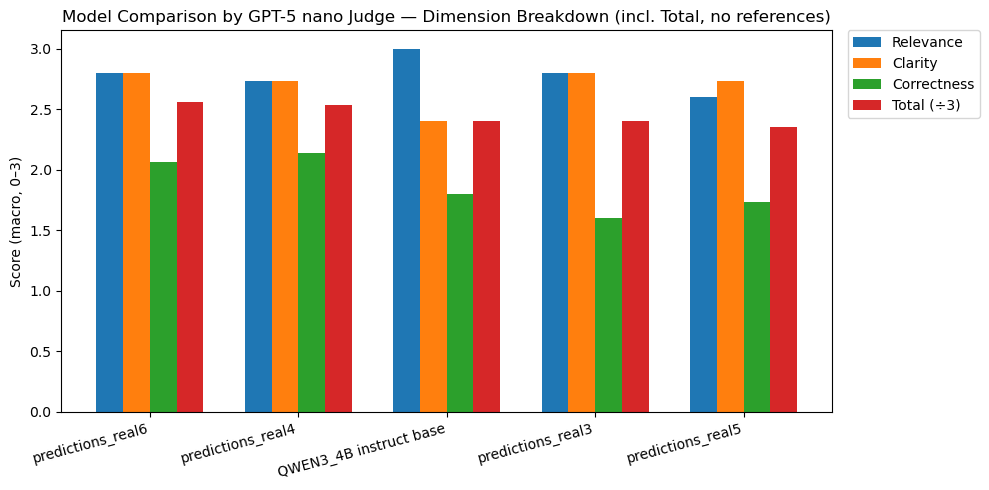

In [47]:
# rescaled total to match 0–3 range of other dimensions
dfp["total_macro_scaled"] = dfp["total_macro"] / 3.0

# Metrics to plot (all on 0–3 scale)
metrics = ["relevance_macro", "clarity_macro", "correctness_macro", "total_macro_scaled"]
metric_labels = ["Relevance", "Clarity", "Correctness", "Total (÷3)"]

x = np.arange(len(dfp))
width = 0.18  # 4 bars per group
offsets = (np.arange(len(metrics)) - (len(metrics)-1)/2) * width

plt.figure(figsize=(10,5))
for i, (mcol, mlabel) in enumerate(zip(metrics, metric_labels)):
    plt.bar(x + offsets[i], dfp[mcol], width=width, label=mlabel)

plt.xticks(x, dfp["label"], rotation=15, ha="right")
plt.ylabel("Score (macro, 0–3)")
plt.title("Model Comparison by GPT-5 nano Judge — Dimension Breakdown (incl. Total, no references)")
# Move legend outside
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.show()


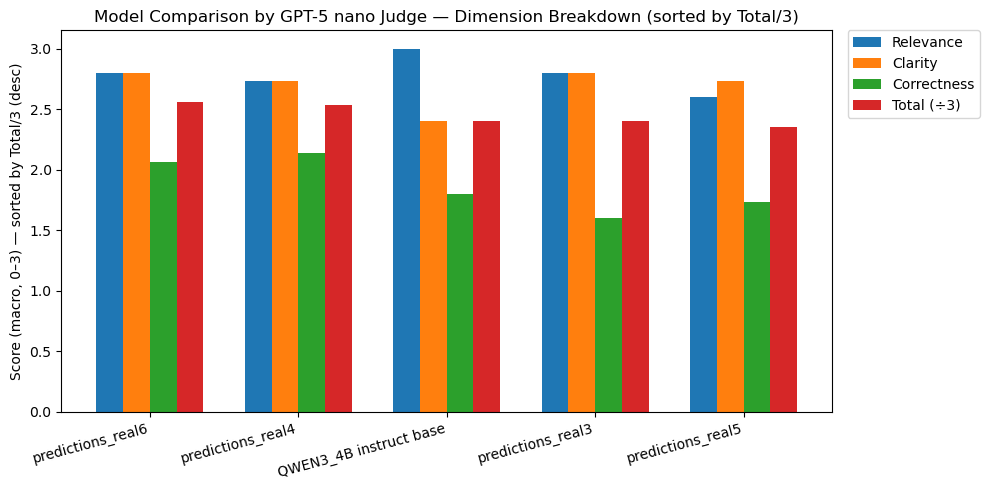

In [48]:
# sort
dfp["total_macro_scaled"] = dfp["total_macro"] / 3.0
dfp = dfp.sort_values("total_macro_scaled", ascending=False).reset_index(drop=True)

# Metrics to plot (all on 0–3 scale)
metrics = ["relevance_macro", "clarity_macro", "correctness_macro", "total_macro_scaled"]
metric_labels = ["Relevance", "Clarity", "Correctness", "Total (÷3)"]

x = np.arange(len(dfp))
width = 0.18  # 4 bars per group
offsets = (np.arange(len(metrics)) - (len(metrics)-1)/2) * width

plt.figure(figsize=(10,5))
for i, (mcol, mlabel) in enumerate(zip(metrics, metric_labels)):
    plt.bar(x + offsets[i], dfp[mcol], width=width, label=mlabel)

plt.xticks(x, dfp["label"], rotation=15, ha="right")
plt.ylabel("Score (macro, 0–3) — sorted by Total/3 (desc)")
plt.title("Model Comparison by GPT-5 nano Judge — Dimension Breakdown (sorted by Total/3)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.show()
